In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [2]:
iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
std_enc = StandardScaler()
X_train = std_enc.fit_transform(X_train)
X_test = std_enc.transform(X_test)

In [8]:
class Softmax:
    def __init__(self, learning_rate=0.01, max_iter=1000, tol=0.0001):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.weights = None
        self.bias = None

    def softmax_(self, z):
        z -= np.max(z, axis=1, keepdims=True)
        exp_scores = np.exp(z)
        return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        self.weights = np.zeros((n_features, n_classes))
        self.bias = np.zeros(n_classes)

        one_hot = np.zeros((len(y), n_classes))
        one_hot[np.arange(len(y)), y] = 1

        for _ in range(self.max_iter):
            logits = np.dot(X, self.weights) + self.bias
            probs = self.softmax_(logits)

            grad_w = (1 / n_samples) * np.dot(X.T, (probs - one_hot))
            grad_b = (1 / n_samples) * np.sum(probs - one_hot, axis=0)

            self.weights = self.weights - self.learning_rate * grad_w
            self.bias = self.bias - self.learning_rate * grad_b

            if np.linalg.norm(grad_w) < self.tol and np.linalg.norm(grad_b) < self.tol:
                break

    def predict_proba(self, X):
        logits = np.dot(X, self.weights) + self.bias
        return self.softmax_(logits)
        

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

In [9]:
model = Softmax(learning_rate=0.1, max_iter=1000, tol=0.0001)
model.fit(X_train, y_train)
preds = model.predict(X_test)

In [10]:
y_test, preds

(array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
        0, 2, 2, 2, 2, 2, 0, 0]),
 array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
        0, 2, 2, 2, 2, 2, 0, 0]))

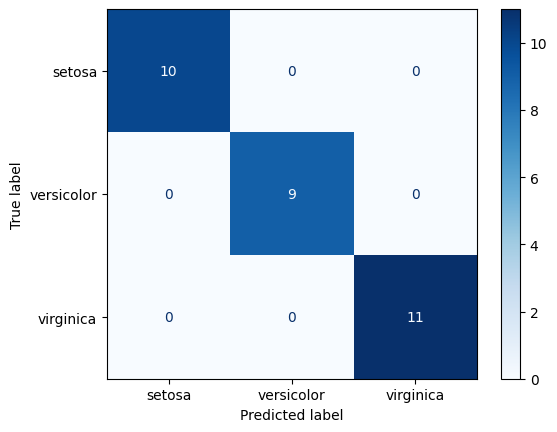

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, preds, display_labels=iris.target_names, cmap='Blues')

## **MNIST**

In [12]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype('int')

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [14]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [15]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial', verbose=1)

model.fit(X_train, y_train)

In [16]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9046428571428572


In [17]:
y_test[:30], y_pred[:30]

(array([8, 4, 8, 7, 7, 0, 6, 2, 7, 4, 3, 9, 9, 8, 2, 5, 9, 1, 7, 8, 0, 0,
        0, 3, 6, 3, 6, 1, 6, 9]),
 array([8, 4, 5, 7, 7, 0, 6, 2, 7, 4, 3, 9, 7, 8, 2, 5, 9, 1, 7, 8, 0, 0,
        0, 3, 6, 3, 6, 1, 6, 9]))

In [18]:
correct = np.sum(y_test == y_pred)
correct_percentage = correct / len(y_test) * 100
print(f"{correct} correct \n{len(y_test)} total ")

12665 correct 
14000 total 


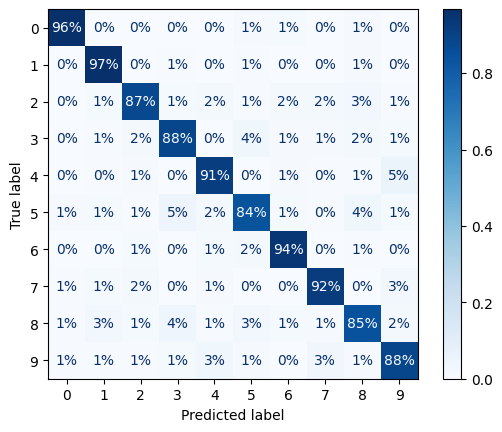

In [19]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=np.unique(y), cmap='Blues', normalize='true', values_format='.0%')

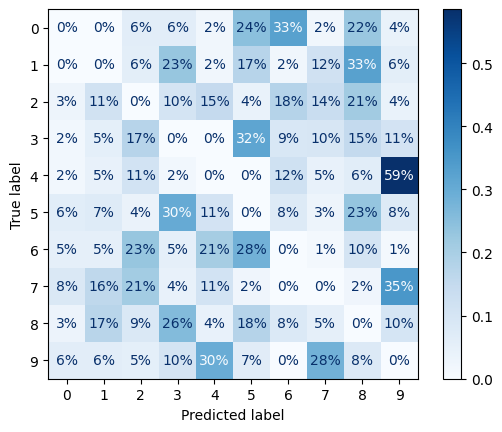

In [20]:
sample_weight = (y_test != y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=np.unique(y), cmap='Blues', normalize='true', values_format='.0%', sample_weight=sample_weight)

In [ ]:
from PIL import Image

def image_prep(image_path):
    img = Image.open(image_path).convert('L')
    img = img.resize((28, 28))
    img_array = np.array(img)
    img_array = img_array / 255.0
    # img_array = img_array.flatten()
    return img_array.reshape(1, -1)

In [23]:
img1 = image_prep("test_pics/n_1.png")
img1_1 = image_prep("test_pics/n_1_1.png")
img2 = image_prep("test_pics/n_2.png")
img3 = image_prep("test_pics/n_3.png")
img3_1 = image_prep("test_pics/n_3_1.png")
img6 = image_prep("test_pics/n_6.png")
img6_1 = image_prep("test_pics/n_6_1.png")
img6_2 = image_prep("test_pics/n_6_2.png")
img_9 = image_prep("test_pics/n_9.png")
img_9_1 = image_prep("test_pics/n_9_1.png")
img_9_2 = image_prep("test_pics/n_9_3.png")


print("Rasm 1:", model.predict(img1)[0])
print("Rasm 1:", model.predict(img1_1)[0])
print("Rasm 2:", model.predict(img2)[0])
print("Rasm 3:", model.predict(img3)[0])
print("Rasm 3:", model.predict(img3_1)[0])
print("Rasm 6:", model.predict(img6)[0])
print("Rasm 6:", model.predict(img6_1)[0])
print("Rasm 6:", model.predict(img6_2)[0])
print("Rasm 9:", model.predict(img_9)[0])
print("Rasm 9:", model.predict(img_9_1)[0])
print("Rasm 9:", model.predict(img_9_2)[0])

Rasm 1: 1
Rasm 1: 1
Rasm 2: 2
Rasm 3: 9
Rasm 3: 3
Rasm 6: 5
Rasm 6: 6
Rasm 6: 7
Rasm 9: 3
Rasm 9: 3
Rasm 9: 9
